In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam


In [2]:
# 1. Đọc và chuẩn bị dữ liệu
# Lưu ý: Upload file CSV vào cùng thư mục hiện tại trên Colab trước khi chạy
file_path = 'x1000kbs_vn30_price_2023_2026.csv'
df = pd.read_csv(file_path)

# Đảm bảo cột time là datetime và sắp xếp theo thời gian
df['time'] = pd.to_datetime(df['time'])
df.sort_values('time', inplace=True)
df.set_index('time', inplace=True)

In [3]:
# 2. Khởi tạo features (X) và target (y)
features = ['open', 'close', 'high', 'low', 'volume']
X = df[features].copy()

# y là giá close của ngày mai (dịch lên 1 hàng)
y = df[['close']].shift(-1)

# Ghép X và y lại để loại bỏ dòng bị NaN (ngày cuối cùng không có dữ liệu ngày mai)
data = pd.concat([X, y.rename(columns={'close': 'target_close'})], axis=1)
data.dropna(inplace=True)

# Chuyển về numpy array
X_clean = data[features].values
y_clean = data[['target_close']].values

In [4]:
# 3. Chuẩn hóa dữ liệu (Scale)
# Sử dụng MinMax scaler tách biệt cho X và y để dễ dàng inverse_transform ở bước cuối
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X_clean)
y_scaled = scaler_y.fit_transform(y_clean)

In [5]:
# 4. Reshape X cho mạng RNN
# RNN yêu cầu input có định dạng 3D: (số lượng mẫu, số bước thời gian, số đặc trưng)
# Dùng dữ liệu 1 ngày dự đoán ngày mai => time_steps = 1
X_reshaped = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

In [6]:
# 5. Chia tập Train/Test (80% Train, 20% Test)
# Lưu ý: Dữ liệu chuỗi thời gian tuyệt đối không được shuffle ngẫu nhiên
train_size = int(len(X_reshaped) * 0.8)
X_train, X_test = X_reshaped[:train_size], X_reshaped[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]

print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm thử: {X_test.shape}")

Kích thước tập huấn luyện: (625, 1, 5)
Kích thước tập kiểm thử: (157, 1, 5)


In [ ]:
# 6. Xây dựng mô hình RNN
model = Sequential()
# Lớp RNN với 50 units (bạn có thể điều chỉnh tham số này)
model.add(SimpleRNN(units=50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
# Lớp Output dự đoán 1 giá trị (giá close ngày mai)
model.add(Dense(units=1))

# Compile mô hình với hàm loss MSE theo yêu cầu
model.compile(optimizer=Adam(learning_rate=0.0008), loss='mse')


In [8]:
# 7. Huấn luyện mô hình
print("\nBắt đầu huấn luyện mô hình...")
history = model.fit(
    X_train, y_train, 
    epochs=69, 
    batch_size=32, 
    validation_data=(X_test, y_test), 
    verbose=1
)



Bắt đầu huấn luyện mô hình...
Epoch 1/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0161 - val_loss: 0.0931
Epoch 2/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 - val_loss: 0.0299
Epoch 3/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.7981e-04 - val_loss: 0.0314
Epoch 4/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4393e-04 - val_loss: 0.0163
Epoch 5/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.4277e-04 - val_loss: 0.0133
Epoch 6/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3011e-04 - val_loss: 0.0111
Epoch 7/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2466e-04 - val_loss: 0.0104
Epoch 8/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2508e-04 - val_loss: 0.0094
Epoch 9/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2055e-04 - val_loss: 0.0092
Epoch 10/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1640e-04 - val_loss: 0.0090
Epoch 11/69
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.1486e-04 - val_loss: 0.0083
Epoch 

In [9]:
# 8. Thực hiện dự đoán trên tập test
y_pred_scaled = model.predict(X_test)

# Đưa các giá trị đã scale về lại mức giá thực tế ban đầu (Inverse Transform)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


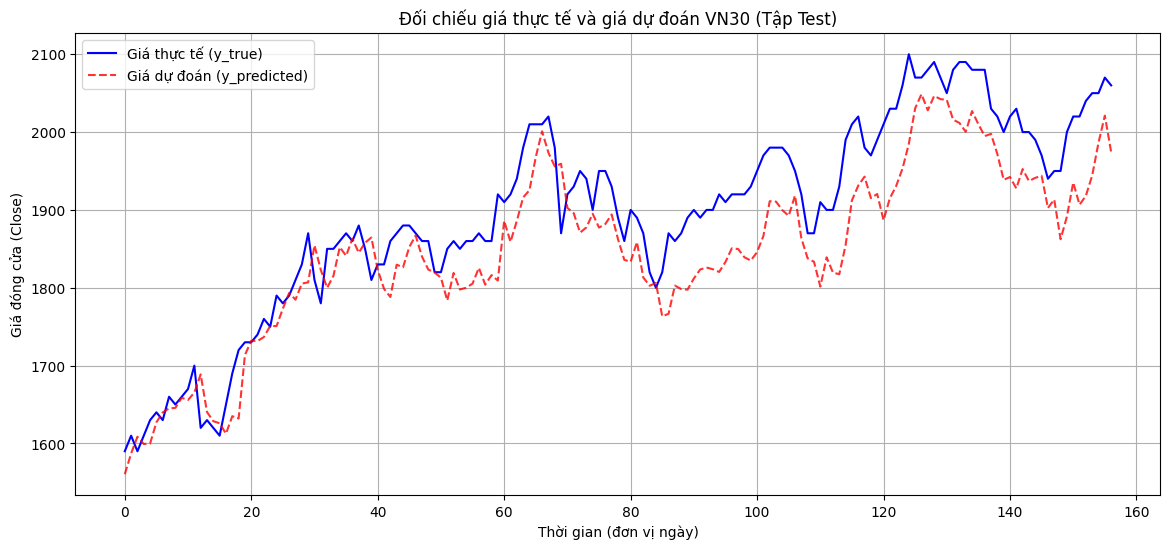

In [10]:
# 9. Vẽ biểu đồ đối chiếu y_true và y_predicted
plt.figure(figsize=(14, 6))
plt.plot(y_true, color='blue', label='Giá thực tế (y_true)')
plt.plot(y_pred, color='red', linestyle='dashed', alpha=0.8, label='Giá dự đoán (y_predicted)')
plt.title('Đối chiếu giá thực tế và giá dự đoán VN30 (Tập Test)')
plt.xlabel('Thời gian (đơn vị ngày)')
plt.ylabel('Giá đóng cửa (Close)')
plt.legend()
plt.grid(True)
plt.show()


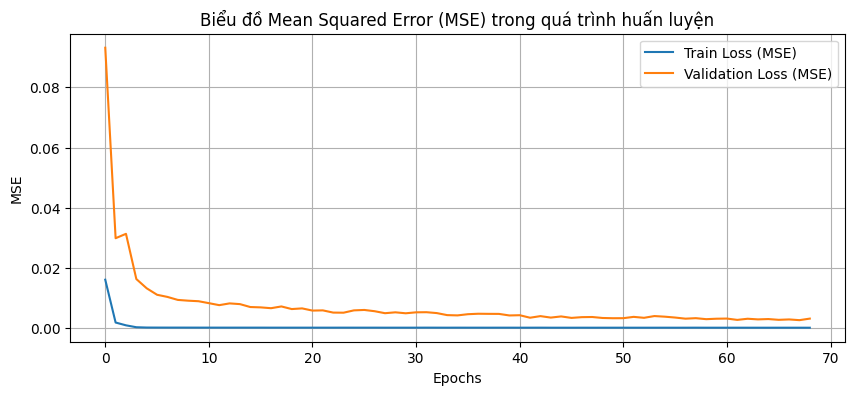

In [11]:
# (Tùy chọn) In biểu đồ lịch sử loss (MSE)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Biểu đồ Mean Squared Error (MSE) trong quá trình huấn luyện')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# ==========================================
# 7. ĐÁNH GIÁ MÔ HÌNH TOÀN DIỆN
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\nKẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST:")
print(f"- MSE (Mean Squared Error)     : {mse:.2f}")
print(f"- MAE (Mean Absolute Error)    : {mae:.2f}")
print(f"- R-squared (Độ phù hợp)       : {r2:.4f}")


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST:
- MSE (Mean Squared Error)     : 3811.73
- MAE (Mean Absolute Error)    : 52.36
- R-squared (Độ phù hợp)       : 0.7623
